# **DATA EXPLORATION TABULAR**

---

## **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats

import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

## **2. Load Raw Data**

Trong giai đoạn đầu của quá trình phân tích thống kê khám phá dữ liệu (EDA), nhóm tiến hành tải tập dữ liệu thô (raw data) từ các tệp CSV được lưu trữ trong cấu trúc thư mục dự án (`data/raw/`). 

Bộ dữ liệu gốc được chia sẵn thành hai tệp `fraudTrain.csv` và `fraudTest.csv`. Để đảm bảo tính khách quan và tránh hiện tượng rò rỉ dữ liệu làm sai lệch các quyết định tiền xử lý, toàn bộ quá trình EDA này sẽ chỉ được thực hiện trên tập huấn luyện (`fraudTrain.csv`).

In [2]:
train_path = "../data/raw/fraudTrain.csv"
# test_path = "../data/raw/fraudTest.csv"

df_train = pd.read_csv(train_path)

Dữ liệu được đọc từ tệp `fraudTrain.csv` thành công và được khởi tạo dưới dạng cấu trúc dữ liệu bảng (tabular), lưu trữ trong biến DataFrame `df_train`.

## **3. Basic Dataset Overview**

### **3.1 Dataset Dimensions**

Bước đầu tiên để nắm bắt quy mô của dữ liệu là kiểm tra chiều không gian (số lượng quan sát và số lượng đặc trưng/thuộc tính).

In [3]:
num_rows_train, num_cols_train = df_train.shape
print(f"Number of rows: {num_rows_train}")
print(f"Number of columns: {num_cols_train}")

Number of rows: 1296675
Number of columns: 23


Tập dữ liệu huấn luyện **Credit Card Transactions Fraud Detection** có quy mô rất lớn, bao gồm *1.296.675 quan sát (giao dịch)* và *23 biến đặc trưng (thuộc tính)*. 

### **3.2 Observational Unit**

Đơn vị quan sát cốt lõi của tập dữ liệu này được xác định như sau:

> **Một bản ghi tương ứng với một giao dịch thẻ tín dụng duy nhất được thực hiện bởi một khách hàng tại một cửa hàng vào một thời điểm cụ thể**.

**Đặc điểm cấu trúc dữ liệu:** Đây là bộ dữ liệu dạng bảng (Tabular Data) mang tính chất không gian - thời gian. Nó kết hợp cả thông tin định danh tĩnh (nhân khẩu học của chủ thẻ), tín hiệu động (số tiền, thời gian giao dịch) và yếu tố địa lý (tọa độ GPS của khách hàng và cửa hàng).

### **3.3 Initial Data Glimpse**

Để có cái nhìn ban đầu về cấu trúc và định dạng của dataset, nhóm hiển thị 5 dòng đầu tiên, 5 dòng cuối cùng và thống kê kiểu dữ liệu tổng quát:

In [4]:
# Xem 5 dòng đầu tiên
display(df_train.head())

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
# Xem 5 dòng cuối
display(df_train.tail())

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0
1296674,1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.30,Jeffrey,Smith,M,135 Joseph Mountains,...,45.8433,-113.8748,218,"Therapist, horticultural",1995-08-16,8f7c8e4ab7f25875d753b422917c98c9,1371816817,46.565983,-114.186110,0


**Summary of Column Types**

In [6]:
dtype_summary = df_train.dtypes.value_counts().reset_index()
dtype_summary.columns = ['Data Type', 'Count']
dtype_summary['Example Features'] = dtype_summary['Data Type'].apply(
    lambda t: [col for col in df_train.columns if df_train[col].dtype == t][:3]
)

print("Data Type Distribution:")
display(dtype_summary)

print("\nDetailed Feature Types:")
numerical_feats = df_train.select_dtypes(include=['float64', 'int64']).columns
categorical_feats = df_train.select_dtypes(include=['object']).columns

print(f" - Numerical Features ({len(numerical_feats)}): {list(numerical_feats)}")
print(f" - Categorical Features ({len(categorical_feats)}): {list(categorical_feats)}")

Data Type Distribution:


,Data Type,Count,Example Features
0,object,12,"[trans_date_trans_time, merchant, category]"
1,int64,6,"[Unnamed: 0, cc_num, zip]"
2,float64,5,"[amt, lat, long]"



Detailed Feature Types:
 - Numerical Features (11): ['Unnamed: 0', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']
 - Categorical Features (12): ['trans_date_trans_time', 'merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num']


Kết quả phân tích cho thấy tập dữ liệu có tổng cộng 23 thuộc tính. Trong đó có 11 biến dạng số (`float64` và `int64`) và 12 biến chuỗi ký tự (`object`). Tuy nhiên, nhiều cột đang ở định dạng `object` thực chất là dữ liệu thời gian (`trans_date_trans_time`, `dob`), đòi hỏi bước ép kiểu (type-casting) trong giai đoạn tiền xử lý.

## **4. Data Semantics**

### **4.1 The meaning of each row**

Mỗi dòng trong bộ dữ liệu đại diện cho một bức tranh toàn cảnh về một giao dịch tài chính. Khi một giao dịch xảy ra, hệ thống lưu vết lại 4 nhóm ngữ cảnh:
1.  **Ai đang giao dịch?** (Thông tin chủ thẻ: tên, tuổi, giới tính, nghề nghiệp, nơi ở).
2.  **Giao dịch ở đâu và cho cái gì?** (Thông tin cửa hàng, danh mục hàng hóa, khoảng cách địa lý).
3.  **Giao dịch như thế nào?** (Số tiền, thời gian thực hiện).
4.  **Nhãn thực tế (Ground truth):** Giao dịch này là bình thường (0) hay gian lận (1).

**Tính chất:** Đây là bài toán *phân loại nhị phân (Binary Classification)* đối mặt với hiện tượng mất cân bằng lớp cực kỳ nghiêm trọng (gian lận thường chỉ chiếm $< 1\%$).

### **4.2 The meaning of each column**

In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

Không gian đặc trưng gồm 23 biến được phân loại thành 6 nhóm ngữ nghĩa chính:

1.  **Identifiers:**
    * `Unnamed: 0`, `trans_num`, `cc_num`: Số thứ tự, mã giao dịch, số thẻ tín dụng. Đây là các định danh duy nhất.
2.  **Transaction Features:**
    * `amt`: Số tiền giao dịch.
    * `category`, `merchant`: Danh mục và tên cửa hàng.
3.  **Temporal Features:**
    * `trans_date_trans_time`, `unix_time`: Thời điểm diễn ra giao dịch.
4.  **Spatial/Location Features:**
    * `lat`, `long`: Tọa độ GPS của khách hàng.
    * `merch_lat`, `merch_long`: Tọa độ GPS của cửa hàng.
5.  **Demographics:**
    * `first`, `last`, `gender`, `dob` (ngày sinh), `job` (nghề nghiệp), thông tin địa chỉ (`street`, `city`, `state`, `zip`, `city_pop`).
6.  **Target Variable:**
    * `is_fraud`: Nhãn 0 (Bình thường) và 1 (Gian lận).

## **5. Distribution Analysis**

Theo yêu cầu tiền xử lý, do kích thước tập dữ liệu $n > 5000$, nhóm áp dụng *kiểm định D'Agostino-Pearson* để đánh giá mức độ phù hợp của dữ liệu với phân phối chuẩn thay vì Shapiro-Wilk.

### **5.1. Overview of D'Agostino-Pearson Omnibus Test**

Kiểm định D'Agostino-Pearson (thường được biết đến với tên gọi Omnibus $K^2$ test hay D'Agostino's $K^2$ test) là một kỹ thuật mạnh mẽ và thường được khuyến nghị để kiểm tra mức độ phù hợp của dữ liệu với phân phối chuẩn. 

Kiểm định này đo lường sự sai khác khỏi phân phối chuẩn bằng cách đánh giá đồng thời hình dáng của phân phối trên hai phương diện: tính bất đối xứng thông qua độ lệch (Skewness) và độ dày của phần đuôi thông qua độ nhọn (Kurtosis). Sau đó, nó tổng hợp những sai lệch này để tính toán ra một p-value duy nhất.

### **5.2. Hypothesis Formulation**

Tương tự các kiểm định tính chuẩn khác, giả thuyết được đặt ra là:
* $H_0$ (Giả thuyết không): Mẫu dữ liệu được rút ra từ một tổng thể có phân phối chuẩn.
* $H_1$ (Giả thuyết thay thế hay đối thuyết): Mẫu dữ liệu không tuân theo phân phối chuẩn.

### **5.3 Core Mathematical Algorithms**

Thống kê Omnibus $K^2$ được cấu thành thông qua 4 bước cơ bản:

**Bước 1: Tính Skewness và Kurtosis mẫu**

Cho một mẫu gồm $n$ quan sát $x_i$, trung bình mẫu $\bar{x}$, và các moment trung tâm mẫu $m_j = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^j$.
* Độ lệch (Skewness): $g_1 = \frac{m_3}{m_2^{3/2}}$
* Độ nhọn dư thừa (Excess Kurtosis): $g_2 = \frac{m_4}{m_2^2} - 3$

**Bước 2: Biến đổi Skewness thành biến chuẩn hóa $Z_1$**

Sử dụng phép biến đổi hàm sinh ngược để tạo ra giá trị $Z_1$ phân phối xấp xỉ chuẩn tắc:
$$Z_1(g_1) = \delta \operatorname{asinh} \left( \frac{g_1}{\alpha \sqrt{\mu_2(g_1)}} \right)$$
*(Trong đó $\mu_2(g_1)$ là phương sai lý thuyết của độ lệch; $\delta$, $\alpha$ là các hằng số phụ thuộc vào độ nhọn lý thuyết).*

**Bước 3: Biến đổi Kurtosis thành biến chuẩn hóa $Z_2$**

Áp dụng phép biến đổi Anscombe & Glynn để đưa độ nhọn $g_2$ về biến $Z_2$ có phân phối xấp xỉ chuẩn tắc (với $n \ge 20$):
$$Z_2(g_2) = \sqrt{\frac{9A}{2}} \left[ 1 - \frac{2}{9A} - \left( \frac{1 - 2/A}{1 + \frac{g_2 - \mu_1(g_2)}{\sqrt{\mu_2(g_2)}} \sqrt{\frac{2}{A-4}}} \right)^{1/3} \right]$$

**Bước 4: Tính thống kê Omnibus $K^2$**

Thống kê kiểm định tổng quát được kết hợp bằng tổng bình phương của hai giá trị đã được chuẩn hóa:
$$K^2 = Z_1(g_1)^2 + Z_2(g_2)^2$$
Nếu giả thuyết $H_0$ đúng, thống kê $K^2$ xấp xỉ tuân theo phân phối Chi-bình phương ($\chi^2$) với 2 bậc tự do.

### **5.4 Decision Rule & Limitations**

* **Tiêu chí:** Nếu p-value $\le 0.05$, ta bác bỏ $H_0$ (dữ liệu không chuẩn). Nếu p-value $> 0.05$, không đủ bằng chứng bác bỏ $H_0$ (dữ liệu phân phối chuẩn).
* **Blind spot:** Kiểm định này chỉ phân tích sự khác biệt qua Skewness và Kurtosis. Nếu một phân phối bất thường nhưng tình cờ có Skewness = 0 và Excess Kurtosis = 0, thuật toán sẽ bỏ sót (Type II error).

### **5.5 Implementation & Distribution Classification**

Nhóm tiến hành trích xuất danh sách các biến định lượng (numerical features) và chạy kiểm định `scipy.stats.normaltest` (cài đặt chuẩn của D'Agostino-Pearson) để phân loại từng thuộc tính.

In [8]:
# Select numerical features
numeric_columns = df_train.select_dtypes(include=['float64', 'int64']).columns
columns_to_exclude = ['Unnamed: 0', 'cc_num', 'zip', 'unix_time', 'is_fraud']
features_to_evaluate = [col for col in numeric_columns if col not in columns_to_exclude]

# Initialize storage
alpha = 0.05
normality_results = []

# Apply D'Agostino-Pearson normality test
for feature in features_to_evaluate:
    data = df_train[feature].dropna()
    
    # Perform normality test
    k2_statistic, p_value = stats.normaltest(data)
    
    # Determine distribution type
    is_gaussian = p_value > alpha
    distribution_label = "Gaussian" if is_gaussian else "Non-Gaussian"
    
    # Compute skewness (additional diagnostic)
    skewness_value = data.skew()
    
    # Store results
    normality_results.append({
        "Feature": feature,
        "K2 Statistic": round(k2_statistic, 3),
        "P-value": p_value,
        "Skewness": round(skewness_value, 3),
        "Distribution": distribution_label,
        "Is Gaussian": is_gaussian
    })

df_normality = pd.DataFrame(normality_results)
display(df_normality)

,Feature,K2 Statistic,P-value,Skewness,Distribution,Is Gaussian
0,amt,3855720.194,0.0,42.278,Non-Gaussian,False
1,lat,25967.329,0.0,-0.186,Non-Gaussian,False
2,long,243229.420,0.0,-1.150,Non-Gaussian,False
3,city_pop,1385384.742,0.0,5.594,Non-Gaussian,False
4,merch_lat,25081.688,0.0,-0.182,Non-Gaussian,False
5,merch_long,242241.655,0.0,-1.147,Non-Gaussian,False


### **5.6 Scaling Strategy Proposal**

#### Distributional Characteristics

Tất cả các thuộc tính số đều có p-value xấp xỉ 0 (p < 0.05), do đó ta *bác bỏ giả thuyết không (H_0)* về việc dữ liệu tuân theo phân phối chuẩn. Nói cách khác, không có thuộc tính nào trong tập dữ liệu có phân phối Gaussian.

Bên cạnh đó, một số thuộc tính thể hiện độ lệch (skewness) đáng kể:

* `amt` có độ lệch phải cực lớn (Skewness = 42.278), cho thấy phân phối có đuôi phải rất dài.
* `city_pop` cũng có độ lệch phải cao.
* Các biến địa lý (`lat`, `long`, `merch_lat`, `merch_long`) có độ lệch nhẹ đến trung bình.

Hiện tượng này phù hợp với dữ liệu thực tế trong bài toán gian lận thẻ tín dụng:

* Phần lớn giao dịch có giá trị nhỏ
* Một số ít giao dịch có giá trị rất lớn (ngoại lai)

#### Implications for Feature Scaling

Do toàn bộ các biến đều không tuân theo phân phối chuẩn, việc áp dụng chuẩn hóa Z-score (StandardScaler) là không phù hợp, vì phương pháp này:

* Giả định dữ liệu gần phân phối chuẩn
* Nhạy cảm với các giá trị ngoại lai

Vì vậy, cần sử dụng các phương pháp chuẩn hóa có khả năng chống chịu ngoại lai và không phụ thuộc phân phối.

#### Recommended Scaling Strategy

Chiến lược chuẩn hóa được đề xuất theo từng nhóm đặc trưng như sau:

* **Biến số tiền giao dịch (`amt`):**

  * Do có độ lệch rất lớn và chứa nhiều ngoại lai:

    * Sử dụng *RobustScaler* (dựa trên Median và IQR), hoặc
    * *QuantileTransformer* (biến đổi phân phối về dạng Uniform hoặc Normal)
  * Mục tiêu là giảm ảnh hưởng của các giá trị cực đoan.

* **Biến dân số (`city_pop`):**

  * Có độ lệch cao → nên:

    * Áp dụng *RobustScaler*, hoặc
    * Kết hợp *log transformation* trước khi chuẩn hóa

* **Các biến tọa độ địa lý (`lat`, `long`, `merch_lat`, `merch_long`):**

  * Là các biến có giới hạn không gian rõ ràng
  * Có thể:

    * Sử dụng *MinMaxScaler* để đưa về khoảng ([0, 1]), giúp bảo toàn cấu trúc không gian
    * Hoặc giữ nguyên nếu được sử dụng để tạo đặc trưng mới (ví dụ: khoảng cách địa lý)


## **6. Multivariate Correlation & Multicollinearity Analysis**

Sau khi phân tích phân phối đơn biến, bước tiếp theo là đánh giá mối quan hệ tương quan đa biến (Multivariate Correlation) giữa các đặc trưng định lượng. Mục tiêu cốt lõi của phần này là phát hiện hiện tượng đa cộng tuyến (Multicollinearity) - tình trạng các biến độc lập tương quan quá mạnh với nhau, làm mất đi tính ổn định của các mô hình tuyến tính ở giai đoạn sau.

### **6.1 Theoretical Foundation: Correlation Metrics**

Để có góc nhìn toàn diện, nhóm kết hợp biểu đồ nhiệt (Heatmap) với hai phương pháp đo lường tương quan thống kê phổ biến nhất: Pearson và Spearman.

**1. Tương quan Pearson (Pearson's Correlation Coefficient - $r$)**
* **Ý nghĩa:** Đo lường độ mạnh và hướng của mối quan hệ tuyến tính giữa hai biến định lượng. 
* **Công thức:** Được tính bằng hiệp phương sai chia cho tích độ lệch chuẩn của hai biến:
$$r = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2 \sum_{i=1}^n (y_i - \bar{y})^2}} = \frac{Cov(x, y)}{\sigma_x \sigma_y}$$
* **Hạn chế:** Rất nhạy cảm với các giá trị ngoại lai (outliers) và chỉ nắm bắt được quan hệ tuyến tính.

**2. Tương quan Spearman (Spearman's Rank Correlation Coefficient - $\rho$)**
* **Ý nghĩa:** Là phương pháp phi tham số đo lường mối quan hệ đơn điệu. Phương pháp này đánh giá mức độ tương quan dựa trên thứ hạng (rank) của các giá trị dữ liệu thay vì dùng giá trị thực tế.
* **Ưu điểm:** Do sử dụng thứ hạng, Spearman kháng lại ngoại lai cực kỳ tốt, rất phù hợp cho tập dữ liệu chứa biến có phân phối bị lệch nghiêm trọng.
* **Công thức:** Khi không có các thứ hạng trùng lặp, công thức được đơn giản hóa thành:
$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$
*(Trong đó: $d_i$ là sự chênh lệch giữa thứ hạng của hai biến đối với cùng một cặp quan sát $i$).*

**3. Tiêu chí phát hiện đa cộng tuyến (Multicollinearity Threshold)**
Nhóm thiết lập ngưỡng phát hiện đa cộng tuyến mạnh là $|r| > 0.9$. Khi vượt quá ngưỡng này, hai biến mang lượng thông tin gần như trùng lặp, gây ra hiện tượng phình to phương sai trong các mô hình học máy.

### **6.2 Bivariate Analysis & Heatmap Visualization**

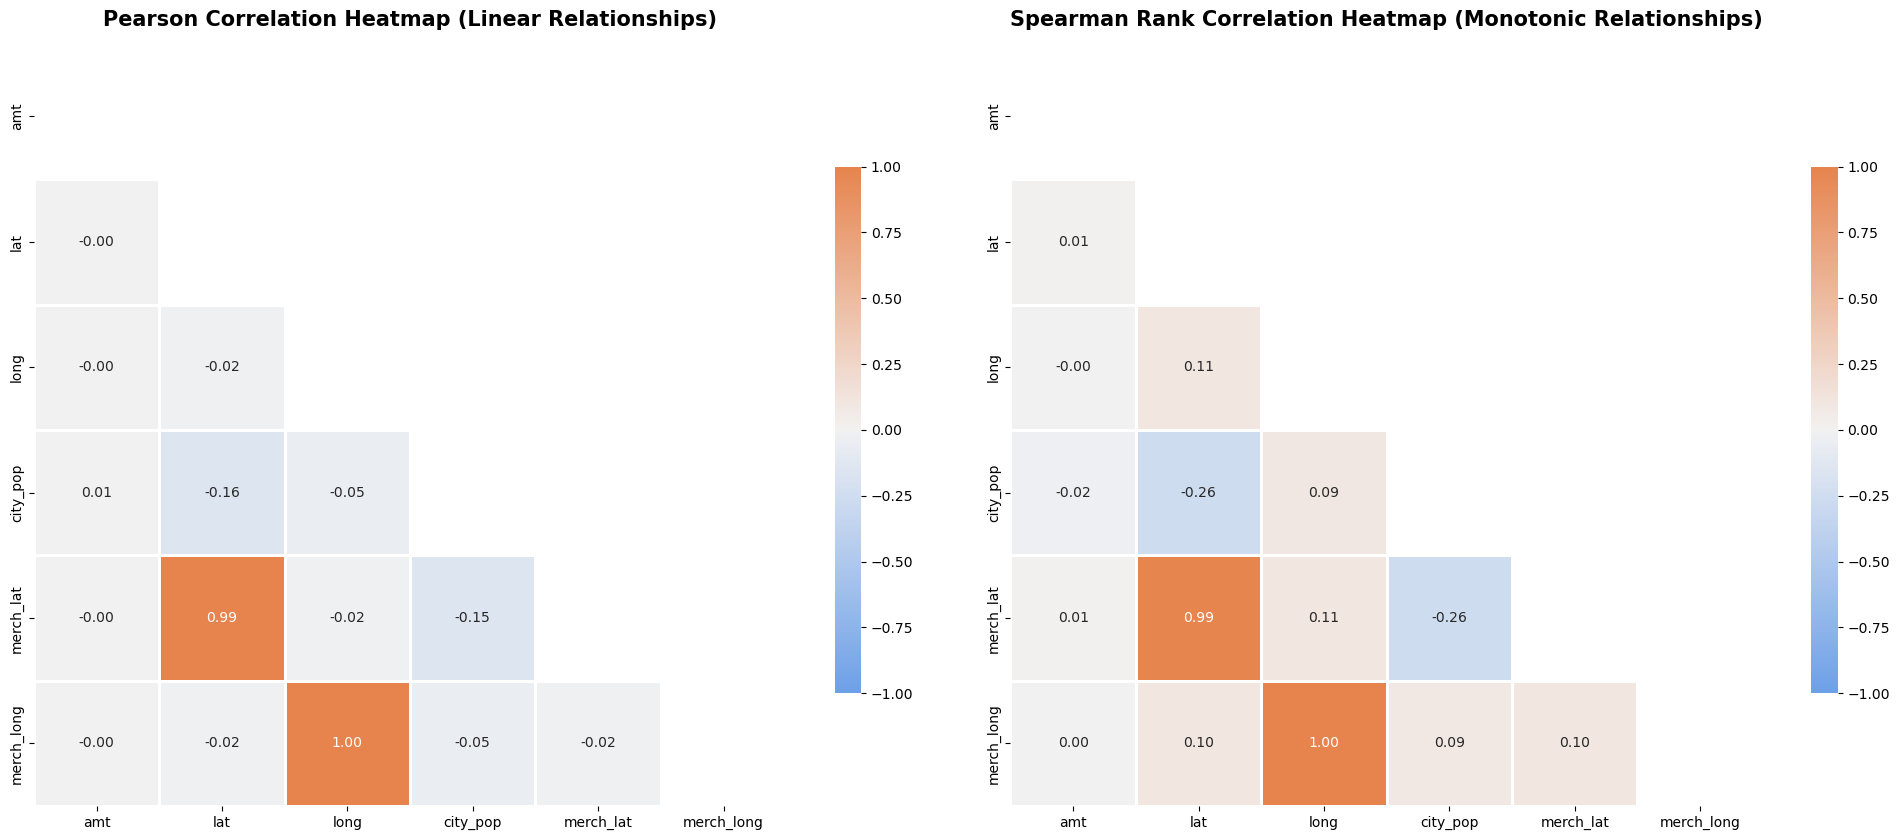

In [9]:
# Select numerical features for correlation analysis
numerical_features = ['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long']
df_corr = df_train[numerical_features]

# Compute correlation matrices
corr_pearson = df_corr.corr(method='pearson')
corr_spearman = df_corr.corr(method='spearman')

# Create upper-triangle mask (avoid duplicate information)
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

cmap = sns.diverging_palette(250, 30, l=65, center="light", as_cmap=True)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap Pearson
sns.heatmap(corr_pearson, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=1, linecolor='white', cbar_kws={"shrink": 0.7}, 
            annot=True, fmt=".2f", ax=axes[0])
axes[0].set_title('Pearson Correlation Heatmap (Linear Relationships)', fontsize=15, fontweight='bold', pad=20)

# Heatmap Spearman
sns.heatmap(corr_spearman, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=1, linecolor='white', cbar_kws={"shrink": 0.7}, 
            annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title('Spearman Rank Correlation Heatmap (Monotonic Relationships)', fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

### **6.3 Multicollinearity Detection & Critical Analysis**

Phân tích ma trận tương quan dựa trên kết quả chạy thực tế bằng cả hai phương pháp Pearson và Spearman, nhóm rút ra các nhận xét sau:

1.  **Nhận diện đa cộng tuyến mạnh ($|r| \ge 0.9$):**

    Cả biểu đồ Pearson và Spearman đều phát tín hiệu cảnh báo đỏ về hiện tượng trùng lặp thông tin tại các biến tọa độ:
    * Cặp `long` và `merch_long` có hệ số tương quan đạt mức tuyệt đối $r = 1.00$ và $\rho = 1.00$.
    * Cặp `lat` và `merch_lat` có hệ số tương quan cực kỳ cao $r = 0.99$ và $\rho = 0.99$.
    * *Giải thích thực tế:* Điều này phản ánh thực tế hành vi tiêu dùng: chủ thẻ tín dụng hầu hết thực hiện giao dịch tại các cửa hàng nằm trong bán kính sinh sống rất hẹp (cùng thành phố/tiểu bang), khiến tọa độ của họ và cửa hàng gần như là một.

2.  **Mối quan hệ phi tuyến, sự khác biệt giữa Pearson và Spearman:**
    * Cặp biến `city_pop` (dân số) và `lat` (vĩ độ) cho thấy sự chênh lệch nhẹ giữa hai phương pháp đo lường (Pearson $r = -0.16$, Spearman $\rho = -0.26$). Sự gia tăng tương quan âm ở Spearman chứng tỏ tồn tại một mối quan hệ đơn điệu nghịch biến (vĩ độ càng cao, dân số có xu hướng giảm), nhưng mối quan hệ này không phải là một đường thẳng hoàn hảo và có thể bị nhiễu bởi các thành phố ngoại lai.
    * Biến `amt` (số tiền giao dịch) hoàn toàn độc lập tuyến tính với tất cả các biến còn lại (các hệ số đều xoay quanh $0.00$ đến $0.01$). 

### **6.4 Proposed Treatments for Multicollinearity**

Với sự xuất hiện của hai cặp biến có $|r| \ge 0.99$, nếu đưa trực tiếp vào các thuật toán hồi quy tuyến tính (như Logistic Regression), hệ thống sẽ gặp hiện tượng phình to phương sai (Variance Inflation Factor - VIF $\to \infty$), làm sai lệch hoàn toàn trọng số mô hình. 

Để khắc phục vấn đề này ở bước tiền xử lý, nhóm đề xuất chiến lược: *kết hợp và loại bỏ (Combine & Drop)*.

* **Bảo toàn thông tin ban đầu:** Mặc dù 4 biến tọa độ trùng lặp nhau, nhưng khoảng cách giữa chúng lại chứa đựng dấu hiệu để phát hiện gian lận. Bọn tội phạm thẻ tín dụng thường quẹt thẻ ở những vị trí địa lý bất thường, cách xa nơi ở của nạn nhân.
* **Thực thi:** Ở notebook Preprocessing, nhóm sẽ áp dụng công thức toán học *Haversine* để tính ra khoảng cách vật lý thực tế (km) dựa trên (`lat`, `long`) và (`merch_lat`, `merch_long`). Đại lượng mới này sẽ được đặt tên là `distance_km`.
* **Loại bỏ đa cộng tuyến:** Sau khi có `distance_km`, toàn bộ 4 cột tọa độ gốc sẽ bị loại bỏ (Drop) khỏi tập dữ liệu. Điều này giúp giải quyết dứt điểm hiện tượng đa cộng tuyến mà không làm thất thoát tri thức nghiệp vụ.

## **7. Missing Value Analysis** 

* Sử dụng thư viện `missingno` để vẽ ma trận thiếu dữ liệu.
    * Thực hiện Little's MCAR test và kết luận cơ chế thiếu (MCAR, MAR, hay MNAR).

---